In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Load COT
cot = pd.read_csv('cot_clean.csv', parse_dates=['date', 'tradeable_date'])

# Load EOD price data
tickers = {'corn': 'ZS=F', 'soy': 'ZC=F', 'hogs': 'HE=F','live_cattle': 'LE=F','feeder_cattle': 'GF=F'}
eod = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start='2000-01-01', auto_adjust=True)
    df.columns = ['_'.join(col).strip('_') for col in df.columns]
    eod[name] = df
    print(f"{name}: {len(df)} rows")

[*********************100%***********************]  1 of 1 completed


corn: 6432 rows


[*********************100%***********************]  1 of 1 completed


soy: 6440 rows


[*********************100%***********************]  1 of 1 completed


hogs: 6363 rows


[*********************100%***********************]  1 of 1 completed


live_cattle: 6295 rows


[*********************100%***********************]  1 of 1 completed

feeder_cattle: 6265 rows


In [2]:
cot_market_map = {
    'CORN - CHICAGO BOARD OF TRADE': ('corn', 'ZS=F'),
    'SOYBEANS - CHICAGO BOARD OF TRADE': ('soy', 'ZC=F'),
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': ('hogs', 'HE=F'),
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': ('live_cattle', 'LE=F'),
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': ('feeder_cattle', 'GF=F')
}

In [5]:
rows = []

for name, df in eod.items():

    close = df.filter(like="Close").iloc[:,0]
    high  = df.filter(like="High").iloc[:,0]
    low   = df.filter(like="Low").iloc[:,0]

    returns = close.pct_change().dropna()
    ranges = (high - low) / close

    rows.append({
        "market": name,
        "volatility": returns.std(),
        "avg_abs_return": returns.abs().mean(),
        "avg_range": ranges.mean()
    })

table = pd.DataFrame(rows)
print(table.round(4))

          market  volatility  avg_abs_return  avg_range
0           corn      0.0157          0.0110     0.0162
1            soy      0.0178          0.0126     0.0197
2           hogs      0.0233          0.0131     0.0161
3          crude      0.0489          0.0185     0.0340
4    live_cattle      0.0113          0.0076     0.0102
5  feeder_cattle      0.0105          0.0069     0.0095


In [6]:
for name, df in eod.items():

    close = df.filter(like="Close").iloc[:,0]
    high  = df.filter(like="High").iloc[:,0]
    low   = df.filter(like="Low").iloc[:,0]

    tmp = pd.DataFrame(index=df.index)
    tmp["ret"] = close.pct_change()
    tmp["day"] = tmp.index.day_name()
    tmp["rng"] = (high - low) / close

    returns = tmp.groupby("day")["ret"].mean()
    stats = tmp.groupby("day")["ret"].std()

    print(name)
    print("RETURNS:")
    print(returns)
    print("VOLATILITY:")
    print(stats)

corn
RETURNS:
day
Friday       0.000295
Monday      -0.000555
Thursday     0.000288
Tuesday      0.000602
Wednesday    0.000596
Name: ret, dtype: float64
VOLATILITY:
day
Friday       0.016544
Monday       0.018456
Thursday     0.014917
Tuesday      0.014988
Wednesday    0.013461
Name: ret, dtype: float64
soy
RETURNS:
day
Friday       0.000389
Monday       0.000136
Thursday     0.000326
Tuesday     -0.000047
Wednesday    0.000679
Name: ret, dtype: float64
VOLATILITY:
day
Friday       0.017389
Monday       0.020533
Thursday     0.017266
Tuesday      0.017477
Wednesday    0.016108
Name: ret, dtype: float64
hogs
RETURNS:
day
Friday       0.000613
Monday      -0.000863
Thursday     0.000329
Tuesday      0.000683
Wednesday    0.000976
Name: ret, dtype: float64
VOLATILITY:
day
Friday       0.020938
Monday       0.028123
Thursday     0.023215
Tuesday      0.024474
Wednesday    0.019079
Name: ret, dtype: float64
crude
RETURNS:
day
Friday       0.001826
Monday      -0.003521
Thursday     0.00145

In [7]:
cot_market_map = {
    'CORN - CHICAGO BOARD OF TRADE': ('corn', 'ZS=F'),
    'SOYBEANS - CHICAGO BOARD OF TRADE': ('soy', 'ZC=F'),
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': ('hogs', 'HE=F'),
    'CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE EXCHANGE': ('crude', 'CL=F'),
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': ('live_cattle', 'LE=F'),
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': ('feeder_cattle', 'GF=F')
}

for cot_name, (short, ticker) in cot_market_map.items():

    price = eod[short].copy()
    if isinstance(price.columns, pd.MultiIndex):
        price.columns = ['_'.join(col).strip('_') for col in price.columns]

    close_col = [c for c in price.columns if "Close" in c][0]
    open_col  = [c for c in price.columns if "Open" in c][0]

    price["oc_ret"] = (price[close_col] - price[open_col]) / price[open_col]

    cot_mkt = cot[cot["Market and Exchange Names"] == cot_name][
        ["tradeable_date", "cot_idx"]
    ].copy()
    
    price = price.reset_index()
    price["Date"] = price["Date"].astype("datetime64[s]")

    cot_mkt["tradeable_date"] = cot_mkt["tradeable_date"].astype("datetime64[s]")
    
    merged = pd.merge_asof(
        price.reset_index().sort_values("Date"),
        cot_mkt.sort_values("tradeable_date"),
        left_on="Date",
        right_on="tradeable_date",
        direction="backward"
    ).set_index("Date")

    mask = (merged.index >= "2008-01-01") & (merged[close_col] != merged[open_col])
    merged = merged[mask].dropna(subset=["cot_idx"])

    merged["signal"] = (merged["cot_idx"] > 0.8).astype(int).shift(1)

    on = merged[merged["signal"] == 1]["oc_ret"]

    print("="*40)
    print(short.upper())
    print(f"Direct test - on-signal mean: {on.mean():.5f}")
    print(f"Signal days/yr: {len(on)/17:.0f}")

CORN
Direct test - on-signal mean: 0.00053
Signal days/yr: 83
SOY
Direct test - on-signal mean: 0.00039
Signal days/yr: 70
HOGS
Direct test - on-signal mean: -0.00089
Signal days/yr: 60
CRUDE
Direct test - on-signal mean: -0.00387
Signal days/yr: 89
LIVE_CATTLE
Direct test - on-signal mean: -0.00009
Signal days/yr: 68
FEEDER_CATTLE
Direct test - on-signal mean: 0.00004
Signal days/yr: 66


In [8]:
cot_market_map = {
    'CORN - CHICAGO BOARD OF TRADE': ('corn', 'ZS=F'),
    'SOYBEANS - CHICAGO BOARD OF TRADE': ('soy', 'ZC=F'),
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': ('hogs', 'HE=F'),
    'CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE EXCHANGE': ('crude', 'CL=F'),
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': ('live_cattle', 'LE=F'),
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': ('feeder_cattle', 'GF=F')
}

for cot_name, (short, ticker) in cot_market_map.items():

    price = eod[short].copy()

    if isinstance(price.columns, pd.MultiIndex):
        price.columns = ['_'.join(col).strip('_') for col in price.columns]

    close_col = next(c for c in price.columns if "Close" in c)
    open_col  = next(c for c in price.columns if "Open" in c)

    price["ret"] = price[close_col].pct_change()
    price["oc_ret"] = (price[close_col] - price[open_col]) / price[open_col]

    cot_mkt = cot[cot["Market and Exchange Names"] == cot_name][
        ["tradeable_date", "cot_idx"]
    ].copy()

    price = price.reset_index()
    price["Date"] = price["Date"].astype("datetime64[s]")
    cot_mkt["tradeable_date"] = cot_mkt["tradeable_date"].astype("datetime64[s]")

    merged = pd.merge_asof(
        price.sort_values("Date"),
        cot_mkt.sort_values("tradeable_date"),
        left_on="Date",
        right_on="tradeable_date",
        direction="backward"
    ).set_index("Date")

    merged = merged.dropna(subset=["cot_idx"])

    merged["overnight"] = merged["ret"] - merged["oc_ret"]
    merged["signal"] = (merged["cot_idx"] > 0.8).astype(int).shift(1)

    on = merged[merged["signal"] == 1]

    print("="*40)
    print(short.upper())
    print(f"Close-to-close on signal: {on['ret'].mean():.5f}")
    print(f"Open-to-close on signal:  {on['oc_ret'].mean():.5f}")
    print(f"Overnight on signal:      {on['overnight'].mean():.5f}")

CORN
Close-to-close on signal: 0.00033
Open-to-close on signal:  0.00072
Overnight on signal:      -0.00039
SOY
Close-to-close on signal: -0.00001
Open-to-close on signal:  0.00041
Overnight on signal:      -0.00042
HOGS
Close-to-close on signal: 0.00133
Open-to-close on signal:  -0.00077
Overnight on signal:      0.00210
CRUDE
Close-to-close on signal: -0.00214
Open-to-close on signal:  -0.00295
Overnight on signal:      0.00081
LIVE_CATTLE
Close-to-close on signal: 0.00020
Open-to-close on signal:  -0.00002
Overnight on signal:      0.00022
FEEDER_CATTLE
Close-to-close on signal: 0.00034
Open-to-close on signal:  0.00004
Overnight on signal:      0.00030


In [9]:
market_map = {
    'CORN - CHICAGO BOARD OF TRADE': 'corn',
    'SOYBEANS - CHICAGO BOARD OF TRADE': 'soy',
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': 'hogs',
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': 'live_cattle',
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': 'feeder_cattle'
}

merged = {}

for cot_name, short_name in market_map.items():

    cot_market = cot[cot['Market and Exchange Names'] == cot_name][
        ['tradeable_date', 'cot_idx', 'spec_idx', 'oi_idx', 'comm_change']
    ].copy()

    price = eod[short_name].copy()

    if isinstance(price.columns, pd.MultiIndex):
        price.columns = [c[0] for c in price.columns]

    price = price.reset_index()
    price["Date"] = price["Date"].astype("datetime64[s]")
    cot_market["tradeable_date"] = cot_market["tradeable_date"].astype("datetime64[s]")

    merged[short_name] = pd.merge_asof(
        price.sort_values('Date'),
        cot_market.sort_values('tradeable_date'),
        left_on='Date',
        right_on='tradeable_date',
        direction='backward'
    ).set_index('Date')

    close_col = next(c for c in merged[short_name].columns if "Close" in c)
    open_col  = next(c for c in merged[short_name].columns if "Open" in c)
    
    merged[short_name]['oc_ret'] = (
        (merged[short_name][close_col] - merged[short_name][open_col]) /
        merged[short_name][open_col]
    )
for name, df in merged.items():
    close_col = next(c for c in df.columns if "Close" in c)
    df["ret"] = df[close_col].pct_change()

for name in ['corn','soy','hogs', 'live_cattle', 'feeder_cattle']:

    d = merged[name].copy()
    d = d[d.index >= '2008-01-01'].dropna(subset=['cot_idx','spec_idx','oi_idx'])

    years = (d.index.max() - d.index.min()).days / 365

    print(f"\n{'='*50}")
    print(f"{name.upper()}")
    print(f"{'Signal':<30} {'On':>8} {'Off':>8} {'Days/yr':>8} {'WR':>8}")

    for label, signal in [
        ('COT only',         (d['cot_idx'] > 0.8)),
        ('COT + spec div',   (d['cot_idx'] > 0.8) & (d['spec_idx'] < 0.2)),
        ('COT + spec + OI',  (d['cot_idx'] > 0.8) & (d['spec_idx'] < 0.2) & (d['oi_idx'] > 0.5)),
    ]:

        sig = signal.astype(int).shift(1)

        on = d[sig == 1]['oc_ret']
        off = d[sig == 0]['oc_ret']

        print(f"{label:<30} {on.mean():>8.5f} {off.mean():>8.5f} {len(on)/years:>8.0f} {(on>0).mean():>8.2%}")


CORN
Signal                               On      Off  Days/yr       WR
COT only                        0.00052  0.00014       78   51.75%
COT + spec div                  0.00048  0.00017       70   51.40%
COT + spec + OI                 0.00081  0.00020       23   53.50%

SOY
Signal                               On      Off  Days/yr       WR
COT only                        0.00038  0.00017       66   50.66%
COT + spec div                  0.00023  0.00022       60   49.86%
COT + spec + OI                 0.00058  0.00019       23   47.60%

HOGS
Signal                               On      Off  Days/yr       WR
COT only                       -0.00088 -0.00041       57   46.63%
COT + spec div                 -0.00074 -0.00046       50   46.56%
COT + spec + OI                 0.00021 -0.00056       13   48.29%

LIVE_CATTLE
Signal                               On      Off  Days/yr       WR
COT only                       -0.00010 -0.00019       64   50.51%
COT + spec div                 -

In [10]:
for name, df in eod.items():

    tmp = df.copy()

    # flatten only if multiindex
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = ['_'.join(c).strip('_') for c in tmp.columns]

    close_col = next(c for c in tmp.columns if "Close" in c)

    r = tmp[close_col].pct_change().dropna()

    print(name)
    print("mean:", r.mean())
    print("std:", r.std())
    print("skew:", r.skew())
    print("kurtosis:", r.kurtosis())
    print()

corn
mean: 0.0002592799714505711
std: 0.01571191929736642
skew: -0.5061291745219942
kurtosis: 15.60419480401745

soy
mean: 0.0002988732480357358
std: 0.01776314665666179
skew: -0.5147962586819523
kurtosis: 10.116458503957858

hogs
mean: 0.00036782141965668224
std: 0.023291713317196115
skew: -0.06322762006688988
kurtosis: 25.869139436310647

crude
mean: -6.671961640386259e-05
std: 0.04888431069121254
skew: -40.714889385586645
kurtosis: 2456.3544580662447

live_cattle
mean: 0.0002512371766583156
std: 0.011318261536606518
skew: -0.7886875321529905
kurtosis: 12.138869910821004

feeder_cattle
mean: 0.000285697201974169
std: 0.01050070847114875
skew: 0.40739730363280297
kurtosis: 12.84243027654492



In [11]:
for name, df in eod.items():

    tmp = df.copy()

    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = ['_'.join(c).strip('_') for c in tmp.columns]

    close_col = next(c for c in tmp.columns if "Close" in c)

    tmp["ret"] = tmp[close_col].pct_change()
    tmp["month"] = tmp.index.month

    stats = tmp.groupby("month")["ret"].std()

    print(name)
    print(stats)
    print()

corn
month
1     0.014026
2     0.012171
3     0.014285
4     0.012537
5     0.014538
6     0.015806
7     0.020299
8     0.019860
9     0.021095
10    0.014540
11    0.013782
12    0.011570
Name: ret, dtype: float64

soy
month
1     0.015483
2     0.012664
3     0.016844
4     0.015422
5     0.018184
6     0.020428
7     0.026687
8     0.016668
9     0.019708
10    0.017246
11    0.014316
12    0.014703
Name: ret, dtype: float64

hogs
month
1     0.014613
2     0.024301
3     0.016799
4     0.033754
5     0.022187
6     0.016136
7     0.019784
8     0.035116
9     0.017390
10    0.027237
11    0.017389
12    0.021311
Name: ret, dtype: float64

crude
month
1     0.024966
2     0.024333
3     0.034306
4     0.149523
5     0.023623
6     0.021639
7     0.019886
8     0.020748
9     0.025949
10    0.022040
11    0.025773
12    0.026239
Name: ret, dtype: float64

live_cattle
month
1     0.009662
2     0.008534
3     0.012310
4     0.011579
5     0.015594
6     0.010873
7     0.011458
8    

In [12]:
def backtest_cot(df, long_thresh=0.8, short_thresh=0.2, silent=False):

    df = df.copy()

    if "ret" not in df.columns:
        close_col = next(c for c in df.columns if "Close" in c)
        df["ret"] = df[close_col].pct_change()

    df = df.dropna(subset=['cot_idx','ret'])

    df['signal'] = 0
    df.loc[df['cot_idx'] > long_thresh, 'signal'] = 1
    df.loc[df['cot_idx'] < short_thresh, 'signal'] = -1

    df['signal'] = df['signal'].shift(1)

    df['strat_ret'] = df['signal'] * df['ret']
    df['equity'] = (1 + df['strat_ret']).cumprod()

    total_ret = df['equity'].iloc[-1] - 1
    annual_ret = (1 + total_ret) ** (252 / len(df)) - 1

    std = df['strat_ret'].std()
    sharpe = 0 if std == 0 else df['strat_ret'].mean() / std * (252 ** 0.5)

    max_dd = (df['equity'] / df['equity'].cummax() - 1).min()

    trades = df[df['signal'] != 0]['strat_ret']
    win_rate = (trades > 0).mean() if len(trades) else 0
    n_trades = len(trades)

    metrics = dict(
        annual=annual_ret,
        sharpe=sharpe,
        max_dd=max_dd,
        win_rate=win_rate,
        n_days=n_trades
    )

    if not silent:
        for k,v in metrics.items():
            print(f"{k}: {v:.3f}")

    return df, metrics

In [13]:
def backtest_cot_sized(df, long_thresh=0.8, short_thresh=0.2, long_only=False,
                       target_vol=0.01, vol_window=20, silent=False):

    df = df.copy()

    if "ret" not in df.columns:
        close_col = next(c for c in df.columns if "Close" in c)
        df["ret"] = df[close_col].pct_change()

    df = df.dropna(subset=['cot_idx','ret'])

    df['signal'] = 0
    df.loc[df['cot_idx'] > long_thresh, 'signal'] = 1
    if not long_only:
        df.loc[df['cot_idx'] < short_thresh, 'signal'] = -1

    df['signal'] = df['signal'].shift(1)

    # realized volatility
    df['vol'] = df['ret'].rolling(vol_window).std()

    # avoid divide-by-zero
    df['vol'] = df['vol'].replace(0, np.nan)

    df['size'] = (target_vol / df['vol']).clip(0.1, 3.0)
    df['size'] = df['size'].shift(1)

    df = df.dropna(subset=['size'])

    df['strat_ret'] = df['signal'] * df['size'] * df['ret']
    df['equity'] = (1 + df['strat_ret']).cumprod()

    total_ret = df['equity'].iloc[-1] - 1
    annual_ret = (1 + total_ret) ** (252 / len(df)) - 1

    std = df['strat_ret'].std()
    sharpe = 0 if std == 0 else df['strat_ret'].mean() / std * (252 ** 0.5)

    max_dd = (df['equity'] / df['equity'].cummax() - 1).min()

    trades = df[df['signal'] != 0]['strat_ret']
    win_rate = (trades > 0).mean() if len(trades) else 0
    n_trades = len(trades)

    metrics = dict(
        annual=annual_ret,
        sharpe=sharpe,
        max_dd=max_dd,
        win_rate=win_rate,
        n_days=n_trades
    )

    if not silent:
        for k, v in metrics.items():
            print(f"{k}: {v:.3f}")

    return df, metrics

In [14]:
periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}
print(f"\nLean Hogs:")
print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")
for period_name, (start, end) in periods.items():
    mask = (merged['hogs'].index >= start) & (merged['hogs'].index <= end)
    period_df = merged['hogs'][mask].copy()
    _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
    print(f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} {m['max_dd']:>8.2%} {m['win_rate']:>8.2%}")


Lean Hogs:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      11.04%    0.657   -8.18%   47.27%
2013-2016       1.87%    0.225  -20.53%   54.58%
2017-2020       0.41%    0.096  -21.71%   47.24%
2021-2024       5.00%    0.387  -21.92%   46.21%


In [15]:
periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}
print(f"\nCorn:")
print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")
for period_name, (start, end) in periods.items():
    mask = (merged['corn'].index >= start) & (merged['corn'].index <= end)
    period_df = merged['corn'][mask].copy()
    _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
    print(f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} {m['max_dd']:>8.2%} {m['win_rate']:>8.2%}")


Corn:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012       5.97%    0.618  -11.74%   55.06%
2013-2016       3.48%    0.376  -16.74%   52.71%
2017-2020       2.62%    0.329  -19.08%   48.41%
2021-2024      -7.10%   -0.651  -26.11%   49.39%


In [16]:
periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}
print(f"\nSoybeans:")
print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")
for period_name, (start, end) in periods.items():
    mask = (merged['soy'].index >= start) & (merged['soy'].index <= end)
    period_df = merged['soy'][mask].copy()
    _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
    print(f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} {m['max_dd']:>8.2%} {m['win_rate']:>8.2%}")


Soybeans:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      -1.44%   -0.136  -18.58%   49.22%
2013-2016      -4.92%   -0.353  -32.89%   50.00%
2017-2020       5.45%    0.640   -9.74%   55.65%
2021-2024       0.94%    0.142  -22.59%   46.94%


In [17]:
periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}
print(f"\nLive Cattle:")
print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")
for period_name, (start, end) in periods.items():
    mask = (merged['live_cattle'].index >= start) & (merged['live_cattle'].index <= end)
    period_df = merged['live_cattle'][mask].copy()
    _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
    print(f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} {m['max_dd']:>8.2%} {m['win_rate']:>8.2%}")


Live Cattle:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      -0.22%    0.022  -22.92%   49.71%
2013-2016      -2.22%   -0.214  -21.56%   48.65%
2017-2020      -2.30%   -0.113  -24.66%   50.76%
2021-2024       2.17%    0.307  -12.64%   53.62%


In [18]:
periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}
print(f"\nFeeder Cattle:")
print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")
for period_name, (start, end) in periods.items():
    mask = (merged['feeder_cattle'].index >= start) & (merged['feeder_cattle'].index <= end)
    period_df = merged['feeder_cattle'][mask].copy()
    _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
    print(f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} {m['max_dd']:>8.2%} {m['win_rate']:>8.2%}")


Feeder Cattle:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012       2.65%    0.370  -13.69%   52.13%
2013-2016      -1.40%   -0.049  -32.36%   47.20%
2017-2020       1.53%    0.217  -14.21%   47.52%
2021-2024       8.38%    0.794  -13.28%   48.36%


In [19]:
markets = ['corn', 'soy']

periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}

for m in markets:
    print(f"\n{'='*40}\n{m.upper()}")
    
    for name, (start,end) in periods.items():
        d = merged[m].loc[start:end]
        
        long_ext  = (d['cot_idx'] > 0.8)
        short_ext = (d['cot_idx'] < 0.2)
        flat      = (~long_ext & ~short_ext)
        
        print(f"\n{name}")
        print(d['cot_idx'].describe()[['mean','std','min','max']])
        print(f"Extreme long:  {long_ext.sum():4d}  ({long_ext.mean():.3f})")
        print(f"Extreme short: {short_ext.sum():4d}  ({short_ext.mean():.3f})")
        print(f"Flat:          {flat.sum():4d}  ({flat.mean():.3f})")


CORN

2008-2012
mean    0.516048
std     0.375919
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   425  (0.338)
Extreme short:  422  (0.335)
Flat:           412  (0.327)

2013-2016
mean    0.607271
std     0.293563
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   332  (0.330)
Extreme short:  114  (0.113)
Flat:           560  (0.557)

2017-2020
mean    0.537068
std     0.316349
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   252  (0.250)
Extreme short:  216  (0.214)
Flat:           539  (0.535)

2021-2024
mean    0.567140
std     0.342006
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   328  (0.326)
Extreme short:  220  (0.219)
Flat:           457  (0.455)

SOY

2008-2012
mean    0.432143
std     0.349380
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   319  (0.253)
Extreme short:  461  (0.366)
Flat:           479  (0.380)

2013-201

In [20]:
markets = ['hogs', 'live_cattle', 'feeder_cattle']

for m in markets:
    print(f"\n{'='*40}\n{m.upper()}")

    for period_name, (start, end) in periods.items():
        d = merged[m].loc[start:end].copy()

        d['signal'] = (d['cot_idx'] > 0.8).astype(int).shift(1)

        on  = d[d['signal']==1]['ret']
        off = d[d['signal']==0]['ret']

        print(period_name)
        print(f"  Avg daily ret on signal: {on.mean():.5f}")
        print(f"  Avg daily ret off signal: {off.mean():.5f}")
        print(f"  N signal days: {len(on)}")


HOGS
2008-2012
  Avg daily ret on signal: 0.00165
  Avg daily ret off signal: 0.00025
  N signal days: 264
2013-2016
  Avg daily ret on signal: 0.00137
  Avg daily ret off signal: -0.00052
  N signal days: 262
2017-2020
  Avg daily ret on signal: -0.00040
  Avg daily ret off signal: 0.00082
  N signal days: 199
2021-2024
  Avg daily ret on signal: 0.00135
  Avg daily ret off signal: 0.00006
  N signal days: 290

LIVE_CATTLE
2008-2012
  Avg daily ret on signal: 0.00004
  Avg daily ret off signal: 0.00039
  N signal days: 350
2013-2016
  Avg daily ret on signal: -0.00016
  Avg daily ret off signal: -0.00000
  N signal days: 259
2017-2020
  Avg daily ret on signal: -0.00001
  Avg daily ret off signal: 0.00012
  N signal days: 264
2021-2024
  Avg daily ret on signal: 0.00037
  Avg daily ret off signal: 0.00064
  N signal days: 207

FEEDER_CATTLE
2008-2012
  Avg daily ret on signal: 0.00007
  Avg daily ret off signal: 0.00039
  N signal days: 199
2013-2016
  Avg daily ret on signal: -0.000

In [21]:
markets = ['hogs', 'live_cattle', 'feeder_cattle']

periods = {
    "2000-2007": ('2000','2007'),
    "2013-2019": ('2013','2019'),
    "2020-2024": ('2020','2024')
}

for m in markets:
    print(f"\n{'='*40}\n{m.upper()}")

    for period_name, (start, end) in periods.items():
        mask = merged[m].index >= '2008-01-01'
        d = merged[m][mask].copy()
        d['signal'] = (d['cot_idx'] > 0.8).astype(int)
        d['signal'] = d['signal'].shift(1)
        long_days = d[d['signal'] == 1]['ret']
        
        print(f"Win rate on signal days: {(long_days > 0).mean():.2%}")
        print(f"Avg winner: {long_days[long_days > 0].mean():.4f}")
        print(f"Avg loser: {long_days[long_days < 0].mean():.4f}")
        print(f"Avg W/L ratio: {long_days[long_days > 0].mean() / abs(long_days[long_days < 0].mean()):.3f}")
        print(f"Max single day loss: {long_days.min():.4f}")
        print(f"Max single day gain: {long_days.max():.4f}")
        print(f"\nConsecutive loss analysis:")
        is_loss = (long_days < 0).astype(int)
        consecutive = is_loss * (is_loss.groupby((is_loss != is_loss.shift()).cumsum()).cumcount() + 1)
        print(f"Max consecutive losing days on signal: {consecutive.max()}")


HOGS
Win rate on signal days: 49.33%
Avg winner: 0.0165
Avg loser: -0.0141
Avg W/L ratio: 1.172
Max single day loss: -0.1592
Max single day gain: 0.2666

Consecutive loss analysis:
Max consecutive losing days on signal: 10
Win rate on signal days: 49.33%
Avg winner: 0.0165
Avg loser: -0.0141
Avg W/L ratio: 1.172
Max single day loss: -0.1592
Max single day gain: 0.2666

Consecutive loss analysis:
Max consecutive losing days on signal: 10
Win rate on signal days: 49.33%
Avg winner: 0.0165
Avg loser: -0.0141
Avg W/L ratio: 1.172
Max single day loss: -0.1592
Max single day gain: 0.2666

Consecutive loss analysis:
Max consecutive losing days on signal: 10

LIVE_CATTLE
Win rate on signal days: 51.88%
Avg winner: 0.0091
Avg loser: -0.0097
Avg W/L ratio: 0.938
Max single day loss: -0.1448
Max single day gain: 0.0703

Consecutive loss analysis:
Max consecutive losing days on signal: 8
Win rate on signal days: 51.88%
Avg winner: 0.0091
Avg loser: -0.0097
Avg W/L ratio: 0.938
Max single day loss

In [22]:
mask = merged['hogs'].index >= '2008-01-01'
d = merged['hogs'][mask].copy()
d['signal'] = (d['cot_idx'] > 0.8).astype(int)
d['signal'] = d['signal'].shift(1)
long_days = d[d['signal'] == 1][['ret']].copy()

long_days['is_loss'] = (long_days['ret'] < 0).astype(int)
long_days['streak'] = long_days['is_loss'] * (
    long_days['is_loss'].groupby(
        (long_days['is_loss'] != long_days['is_loss'].shift()).cumsum()
    ).cumcount() + 1
)

# Find where the worst streaks occurred
streaks = long_days[long_days['streak'] >= 5]
print(streaks[['ret', 'streak']])

                 ret  streak
Date                        
2009-03-20 -0.004835       5
2009-03-23 -0.017814       6
2009-04-28 -0.040909       5
2009-04-29 -0.045024       6
2009-04-30 -0.038875       7
2009-06-04 -0.000436       5
2009-06-05 -0.001746       6
2009-06-26 -0.006570       5
2009-07-23 -0.018518       5
2009-08-07 -0.044542       6
2009-08-10 -0.010246       7
2009-08-11 -0.002588       8
2009-08-12 -0.008822       9
2009-09-22 -0.005484       5
2012-05-02 -0.020783       5
2015-03-11 -0.028041       5
2015-03-12 -0.028460       6
2015-03-13 -0.003210       7
2015-08-21 -0.029730       5
2015-12-08 -0.002704       5
2018-03-27 -0.004739       5
2018-03-28 -0.014286       6
2018-08-01 -0.014315       5
2018-08-02 -0.021162       6
2018-08-03 -0.008054       7
2018-08-06 -0.032479       8
2018-08-07 -0.014134       9
2018-08-08 -0.017921      10
2020-04-02 -0.091463       5
2022-04-04 -0.018263       5
2022-04-05 -0.017848       6
2022-05-06 -0.005837       5
2022-05-09 -0.

In [23]:
for name, df in merged.items():

    d = df.loc['2008-01-01':].copy()

    close_col = next(c for c in d.columns if "Close" in c)
    open_col  = next(c for c in d.columns if "Open" in c)

    d['oc_ret'] = (d[close_col] - d[open_col]) / d[open_col]

    d['signal'] = (d['cot_idx'] > 0.8).astype(int).shift(1)

    long_days = d[d['signal'] == 1]

    print("\n", "="*40)
    print(name.upper())

    print(f"Avg open→close on signal: {long_days['oc_ret'].mean():.5f}")
    print(f"Avg open→close off signal: {d[d['signal']==0]['oc_ret'].mean():.5f}")
    print(f"Win rate: {(long_days['oc_ret'] > 0).mean():.2%}")

    winners = long_days[long_days['oc_ret'] > 0]['oc_ret']
    losers  = long_days[long_days['oc_ret'] < 0]['oc_ret']

    print(f"Avg winner: {winners.mean():.4f}")
    print(f"Avg loser:  {losers.mean():.4f}")
    print(f"Max loss:   {long_days['oc_ret'].min():.4f}")


CORN
Avg open→close on signal: 0.00052
Avg open→close off signal: 0.00014
Win rate: 51.75%
Avg winner: 0.0102
Avg loser:  -0.0103
Max loss:   -0.0827

SOY
Avg open→close on signal: 0.00038
Avg open→close off signal: 0.00017
Win rate: 50.66%
Avg winner: 0.0122
Avg loser:  -0.0122
Max loss:   -0.0756

HOGS
Avg open→close on signal: -0.00088
Avg open→close off signal: -0.00041
Win rate: 46.63%
Avg winner: 0.0107
Avg loser:  -0.0112
Max loss:   -0.0714

LIVE_CATTLE
Avg open→close on signal: -0.00010
Avg open→close off signal: -0.00019
Win rate: 50.51%
Avg winner: 0.0074
Avg loser:  -0.0080
Max loss:   -0.0664

FEEDER_CATTLE
Avg open→close on signal: 0.00004
Avg open→close off signal: -0.00015
Win rate: 48.29%
Avg winner: 0.0065
Avg loser:  -0.0062
Max loss:   -0.0320


In [24]:
for name, df in merged.items():

    d = df.loc['2008-01-01':].copy()

    close_col = next(c for c in d.columns if "Close" in c)

    # close-to-close return
    d['ret'] = d[close_col].pct_change()

    d['signal'] = (d['cot_idx'] > 0.9).astype(int).shift(1)

    long_days = d[d['signal'] == 1]

    print("\n", "="*40)
    print(name.upper())

    print(f"Avg close→close on signal: {long_days['ret'].mean():.5f}")
    print(f"Avg close→close off signal: {d[d['signal']==0]['ret'].mean():.5f}")
    print(f"Win rate: {(long_days['ret'] > 0).mean():.2%}")

    winners = long_days[long_days['ret'] > 0]['ret']
    losers  = long_days[long_days['ret'] < 0]['ret']

    print(f"Avg winner: {winners.mean():.4f}")
    print(f"Avg loser:  {losers.mean():.4f}")
    print(f"Max loss:   {long_days['ret'].min():.4f}")


CORN
Avg close→close on signal: -0.00024
Avg close→close off signal: 0.00020
Win rate: 49.55%
Avg winner: 0.0123
Avg loser:  -0.0129
Max loss:   -0.2087

SOY
Avg close→close on signal: 0.00099
Avg close→close off signal: 0.00002
Win rate: 50.45%
Avg winner: 0.0141
Avg loser:  -0.0129
Max loss:   -0.0792

HOGS
Avg close→close on signal: 0.00118
Avg close→close off signal: 0.00026
Win rate: 48.84%
Avg winner: 0.0168
Avg loser:  -0.0139
Max loss:   -0.1509

LIVE_CATTLE
Avg close→close on signal: -0.00022
Avg close→close off signal: 0.00037
Win rate: 50.47%
Avg winner: 0.0098
Avg loser:  -0.0106
Max loss:   -0.1448

FEEDER_CATTLE
Avg close→close on signal: 0.00038
Avg close→close off signal: 0.00033
Win rate: 50.07%
Avg winner: 0.0081
Avg loser:  -0.0075
Max loss:   -0.0350


Annual return: -1.26%
Sharpe:        -0.002
Max DD:        -59.78%
Win rate:      50.08%


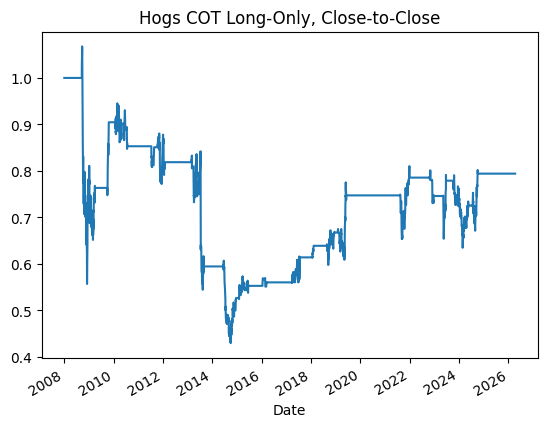

In [25]:
mask = merged['soy'].index >= '2008-01-01'
d = merged['soy'][mask].copy()

close_col = next(c for c in d.columns if "Close" in c)

# close-to-close return
d['ret'] = d[close_col].pct_change()

d['signal'] = (d['cot_idx'] > 0.8).astype(int)
d['signal'] = d['signal'].shift(1)

d['strat_ret'] = d['signal'] * d['ret']
d['equity'] = (1 + d['strat_ret']).cumprod()

total_ret = d['equity'].iloc[-1] - 1
annual_ret = (1 + total_ret) ** (252 / len(d)) - 1
sharpe = d['strat_ret'].mean() / d['strat_ret'].std() * (252 ** 0.5)
max_dd = (d['equity'] / d['equity'].cummax() - 1).min()

print(f"Annual return: {annual_ret:.2%}")
print(f"Sharpe:        {sharpe:.3f}")
print(f"Max DD:        {max_dd:.2%}")
print(f"Win rate:      {(d[d['signal']==1]['ret'] > 0).mean():.2%}")

d['equity'].plot(title='Hogs COT Long-Only, Close-to-Close')
plt.show()

Annual return: 0.53%
Sharpe:        0.104
Max DD:        -27.79%
Win rate:      51.88%


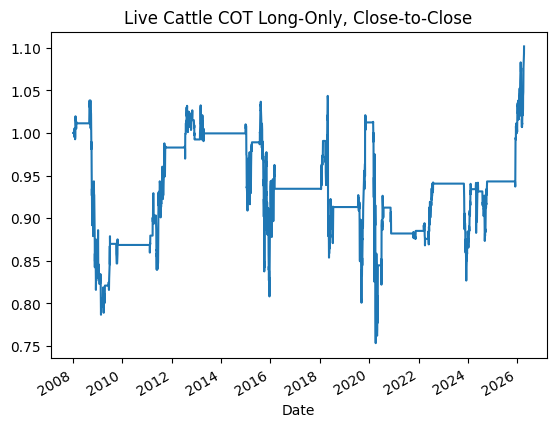

In [26]:
mask = merged['live_cattle'].index >= '2008-01-01'
d = merged['live_cattle'][mask].copy()

close_col = next(c for c in d.columns if "Close" in c)

# close-to-close return
d['ret'] = d[close_col].pct_change()

d['signal'] = (d['cot_idx'] > 0.8).astype(int)
d['signal'] = d['signal'].shift(1)

d['strat_ret'] = d['signal'] * d['ret']
d['equity'] = (1 + d['strat_ret']).cumprod()

total_ret = d['equity'].iloc[-1] - 1
annual_ret = (1 + total_ret) ** (252 / len(d)) - 1
sharpe = d['strat_ret'].mean() / d['strat_ret'].std() * (252 ** 0.5)
max_dd = (d['equity'] / d['equity'].cummax() - 1).min()

print(f"Annual return: {annual_ret:.2%}")
print(f"Sharpe:        {sharpe:.3f}")
print(f"Max DD:        {max_dd:.2%}")
print(f"Win rate:      {(d[d['signal']==1]['ret'] > 0).mean():.2%}")

d['equity'].plot(title='Live Cattle COT Long-Only, Close-to-Close')
plt.show()

Annual return: 2.38%
Sharpe:        0.304
Max DD:        -28.89%
Win rate:      49.69%


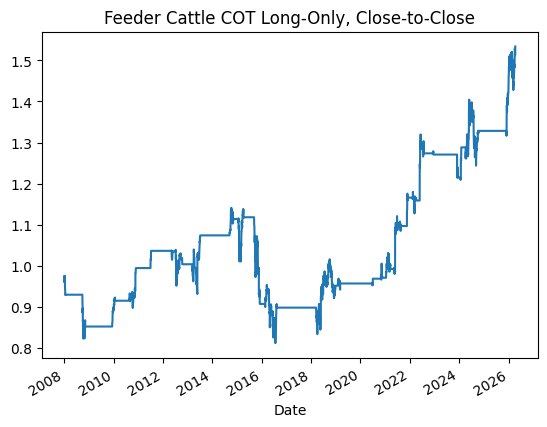

In [27]:
mask = merged['feeder_cattle'].index >= '2008-01-01'
d = merged['feeder_cattle'][mask].copy()

close_col = next(c for c in d.columns if "Close" in c)

# close-to-close return
d['ret'] = d[close_col].pct_change()

d['signal'] = (d['cot_idx'] > 0.8).astype(int)
d['signal'] = d['signal'].shift(1)

d['strat_ret'] = d['signal'] * d['ret']
d['equity'] = (1 + d['strat_ret']).cumprod()

total_ret = d['equity'].iloc[-1] - 1
annual_ret = (1 + total_ret) ** (252 / len(d)) - 1
sharpe = d['strat_ret'].mean() / d['strat_ret'].std() * (252 ** 0.5)
max_dd = (d['equity'] / d['equity'].cummax() - 1).min()

print(f"Annual return: {annual_ret:.2%}")
print(f"Sharpe:        {sharpe:.3f}")
print(f"Max DD:        {max_dd:.2%}")
print(f"Win rate:      {(d[d['signal']==1]['ret'] > 0).mean():.2%}")

d['equity'].plot(title='Feeder Cattle COT Long-Only, Close-to-Close')
plt.show()

In [28]:
# Finding:
# Hog COT extremes (>0.8) show ~0.09% positive next-day drift.
# Effect appears mostly overnight rather than intraday.
# Strategy Sharpe ~0.3 and unstable across regimes → not directly tradable.

In [29]:
from scipy import stats
markets = ['corn', 'soy']
for m in markets:
    print(f'\nMarket:', m)
    d = merged[m].loc['2008':].copy()
    
    close_col = next(c for c in d.columns if "Close" in c)
    d['ret'] = d[close_col].pct_change()
    
    d['signal'] = (d['cot_idx'] > 0.8).astype(int).shift(1)
    
    signal_returns = d[d['signal']==1]['ret'].dropna()
    off_returns = d[d['signal']==0]['ret'].dropna()
    
    t_stat, p_value = stats.ttest_ind(signal_returns, off_returns, equal_var=False)
    
    print("Signal mean:", signal_returns.mean())
    print("Off mean:", off_returns.mean())
    print("t-stat:", t_stat)
    print("p-value:", p_value)


Market: corn
Signal mean: 0.00016701357099529573
Off mean: 8.86809400056363e-05
t-stat: 0.1463713859181202
p-value: 0.8836407705355802

Market: soy
Signal mean: -4.911977548783286e-06
Off mean: 0.00021744524257728343
t-stat: -0.35333182436241095
p-value: 0.7238764086264067


In [30]:
for m in markets: 
    print(f'\nMarket:', m)
    d = merged[m].loc['2008':].copy()
    
    close_col = next(c for c in d.columns if "Close" in c)
    open_col  = next(c for c in d.columns if "Open" in c)
    
    d['cc'] = d[close_col].pct_change()
    d['oc'] = (d[close_col] - d[open_col]) / d[open_col]
    d['overnight'] = d['cc'] - d['oc']
    
    d['signal'] = (d['cot_idx'] > 0.8).astype(int).shift(1)
    
    print("Close→Close:", d[d.signal==1]['cc'].mean())
    print("Open→Close:", d[d.signal==1]['oc'].mean())
    print("Overnight:", d[d.signal==1]['overnight'].mean())


Market: corn
Close→Close: 0.00016701357099529573
Open→Close: 0.0005215108363918259
Overnight: -0.0003544972653965302

Market: soy
Close→Close: -4.911977548783286e-06
Open→Close: 0.00038304384861835436
Overnight: -0.00038795582616713773


In [31]:
thresholds = [0.7,0.8,0.9,0.95]

for m in markets: 
    print(f'\nMarket:', m)
    d = merged[m].loc['2008':].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    d['ret'] = d[close_col].pct_change()
    
    for t in thresholds:
        
        sig = (d['cot_idx'] > t).astype(int).shift(1)
        
        on = d[sig==1]['ret'].mean()
        off = d[sig==0]['ret'].mean()
        n = sig.sum()
        
        print(f"Threshold {t}:")
        print(f"  mean on: {on:.5f}")
        print(f"  mean off: {off:.5f}")
        print(f"  signals/yr: {n/17:.0f}")
        print()


Market: corn
Threshold 0.7:
  mean on: -0.00007
  mean off: 0.00024
  signals/yr: 111

Threshold 0.8:
  mean on: 0.00017
  mean off: 0.00009
  signals/yr: 84

Threshold 0.9:
  mean on: -0.00024
  mean off: 0.00020
  signals/yr: 52

Threshold 0.95:
  mean on: -0.00051
  mean off: 0.00021
  signals/yr: 36


Market: soy
Threshold 0.7:
  mean on: -0.00013
  mean off: 0.00031
  signals/yr: 93

Threshold 0.8:
  mean on: -0.00000
  mean off: 0.00022
  signals/yr: 71

Threshold 0.9:
  mean on: 0.00099
  mean off: 0.00002
  signals/yr: 39

Threshold 0.95:
  mean on: 0.00047
  mean off: 0.00012
  signals/yr: 30



In [32]:
d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()
d['month'] = d.index.month

d['signal'] = (d['cot_idx'] > 0.8).astype(int).shift(1)

for m in range(1,13):

    sub = d[d.month==m]
    on = sub[sub.signal==1]['ret'].mean()
    
    print(f"Month {m}: {on:.5f}")

Month 1: -0.00184
Month 2: -0.00093
Month 3: 0.00118
Month 4: 0.00002
Month 5: 0.00203
Month 6: 0.00094
Month 7: -0.00651
Month 8: -0.00008
Month 9: -0.00053
Month 10: 0.00166
Month 11: -0.00205
Month 12: 0.00335


In [33]:
import numpy as np

signal_returns = d[d.signal==1]['ret'].dropna()

boot = []

for i in range(1000):

    sample = np.random.choice(d['ret'].dropna(), size=len(signal_returns))
    boot.append(sample.mean())

print("Signal mean:", signal_returns.mean())
print("Random mean:", np.mean(boot))

Signal mean: -4.911977548783286e-06
Random mean: 0.00015882807156371791


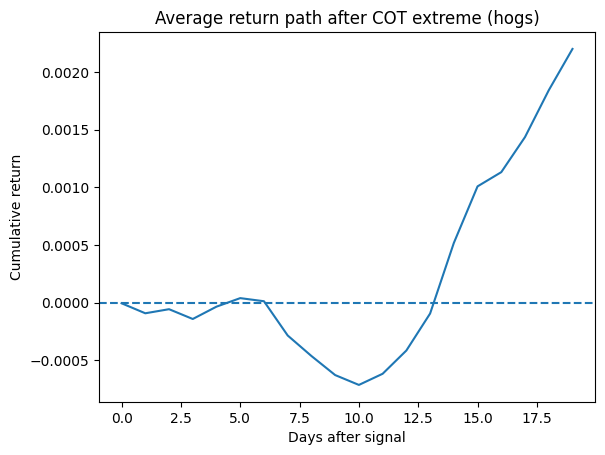

In [34]:
import numpy as np
import matplotlib.pyplot as plt

d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# signal definition
d['signal'] = (d['cot_idx'] > 0.8).astype(int)

horizon = 20
paths = []

for i in range(len(d) - horizon):
    
    if d['signal'].iloc[i] == 1:
        future = d['ret'].iloc[i+1:i+1+horizon].values
        paths.append(np.cumsum(future))

paths = np.array(paths)

avg_path = paths.mean(axis=0)

plt.plot(avg_path)
plt.axhline(0, linestyle='--')
plt.title("Average return path after COT extreme (hogs)")
plt.xlabel("Days after signal")
plt.ylabel("Cumulative return")
plt.show()

In [35]:
future20 = []

for i in range(len(d) - 20):
    if d['signal'].iloc[i] == 1:
        r = d['ret'].iloc[i+1:i+21].sum()
        future20.append(r)

future20 = np.array(future20)

print("Mean 20-day return:", future20.mean())
print("Win rate:", (future20 > 0).mean())
print("Number of signals:", len(future20))

Mean 20-day return: 0.0021990813236734456
Win rate: 0.5389072847682119
Number of signals: 1208


In [36]:
import numpy as np

d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

d['signal'] = (d['cot_idx'] > 0.8).astype(int)

window = 20
future = []

i = window

while i < len(d) - window:
    
    if d['signal'].iloc[i] == 1:
        
        r = d['ret'].iloc[i+1:i+1+window].sum()
        future.append(r)
        
        i += window   # skip forward to avoid overlap
        
    else:
        i += 1

future = np.array(future)

print("Mean 20-day return:", future.mean())
print("Win rate:", (future > 0).mean())
print("Independent signals:", len(future))

Mean 20-day return: -0.0023871307604649093
Win rate: 0.5066666666666667
Independent signals: 75


In [37]:
d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# change in positioning
d['cot_change'] = d['cot_idx'].diff(5)

# signal: extreme AND rising
d['signal2'] = (d['cot_idx'] > 0.8) & (d['cot_change'] > 0)

d['signal2'] = d['signal2'].shift(1)

future = []

for i in range(len(d)-20):

    if d['signal2'].iloc[i]:
        r = d['ret'].iloc[i+1:i+21].sum()
        future.append(r)

import numpy as np
future = np.array(future)

print("Mean 20d return:", future.mean())
print("Win rate:", (future > 0).mean())
print("Signals:", len(future))

Mean 20d return: -0.0019660946134017936
Win rate: 0.5246179966044142
Signals: 589


In [38]:
d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# detect entry into extreme
d['signal_cross'] = (d['cot_idx'] > 0.8) & (d['cot_idx'].shift(1) <= 0.8)

future = []

for i in range(len(d)-20):

    if d['signal_cross'].iloc[i]:
        r = d['ret'].iloc[i+1:i+21].sum()
        future.append(r)

import numpy as np
future = np.array(future)

print("Mean 20d return:", future.mean())
print("Win rate:", (future > 0).mean())
print("Signals:", len(future))

Mean 20d return: -0.01546225116011683
Win rate: 0.5405405405405406
Signals: 37


In [39]:
import numpy as np

d = merged['soy'].loc['2008':].copy()

# extreme regime
d['extreme'] = d['cot_idx'] > 0.8

durations = []
current = 0

for x in d['extreme']:

    if x:
        current += 1
    else:
        if current > 0:
            durations.append(current)
        current = 0

durations = np.array(durations)

print("Number of extreme regimes:", len(durations))
print("Average duration:", durations.mean())
print("Median duration:", np.median(durations))
print("Max duration:", durations.max())

Number of extreme regimes: 37
Average duration: 32.648648648648646
Median duration: 15.0
Max duration: 135


In [40]:
d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# detect entry into bearish extreme
d['signal_short'] = (d['cot_idx'] < 0.2) & (d['cot_idx'].shift(1) >= 0.2)

future = []

for i in range(len(d)-20):
    
    if d['signal_short'].iloc[i]:
        r = d['ret'].iloc[i+1:i+21].sum()
        future.append(r)

import numpy as np
future = np.array(future)

print("Mean 20d return:", future.mean())
print("Win rate:", (future < 0).mean())  # negative returns are "wins" here
print("Signals:", len(future))

Mean 20d return: 0.007441552713887746
Win rate: 0.41935483870967744
Signals: 31


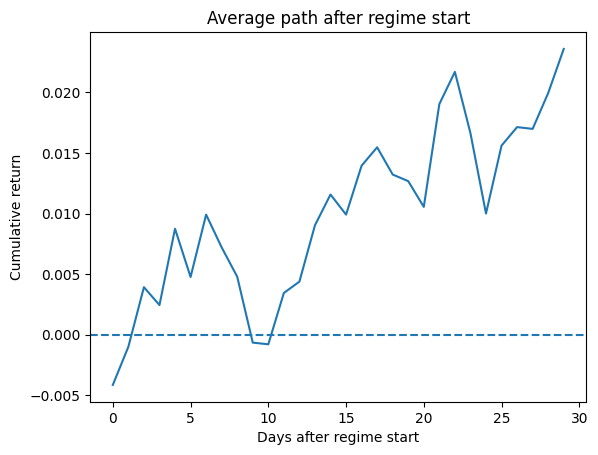

In [41]:
import numpy as np
import matplotlib.pyplot as plt

d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# regime start
d['signal_cross'] = (d['cot_idx'] > 0.9) & (d['cot_idx'].shift(1) <= 0.9)

horizon = 30
paths = []

for i in range(len(d)-horizon):

    if d['signal_cross'].iloc[i]:
        future = d['ret'].iloc[i+1:i+1+horizon].values
        paths.append(np.cumsum(future))

paths = np.array(paths)
avg_path = paths.mean(axis=0)

plt.plot(avg_path)
plt.axhline(0, linestyle='--')
plt.title("Average path after regime start")
plt.xlabel("Days after regime start")
plt.ylabel("Cumulative return")
plt.show()

In [42]:
d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# speculator extreme long
d['spec_long'] = (d['spec_idx'] > 0.8) & (d['spec_idx'].shift(1) <= 0.8)

future = []

for i in range(len(d)-20):

    if d['spec_long'].iloc[i]:
        r = d['ret'].iloc[i+1:i+21].sum()
        future.append(r)

future = np.array(future)

print("Mean 20d return:", future.mean())
print("Win rate:", (future < 0).mean())
print("Signals:", len(future))

Mean 20d return: 0.013149090382761686
Win rate: 0.4
Signals: 30


In [43]:
import pandas as pd

d = merged['soy'].loc['2008':].copy()

# regime start
d['signal_cross'] = (d['cot_idx'] > 0.8) & (d['cot_idx'].shift(1) <= 0.8)

years = d[d['signal_cross']].index.year

print(years.value_counts().sort_index())

Date
2008    1
2009    1
2010    3
2011    3
2012    1
2013    4
2014    2
2015    5
2016    3
2017    1
2018    3
2019    2
2021    1
2022    3
2023    3
2024    1
Name: count, dtype: int64


In [44]:
d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

d['signal_cross'] = (d['cot_idx'] > 0.8) & (d['cot_idx'].shift(1) <= 0.8)

trades = []

for i in range(len(d)-20):

    if d['signal_cross'].iloc[i]:

        r = d['ret'].iloc[i+1:i+21].sum()
        trades.append(r)

import numpy as np
trades = np.array(trades)

print("Trades:", len(trades))
print("Mean return:", trades.mean())
print("Win rate:", (trades>0).mean())
print("Best trade:", trades.max())
print("Worst trade:", trades.min())

Trades: 37
Mean return: -0.01546225116011683
Win rate: 0.5405405405405406
Best trade: 0.11528633919092501
Worst trade: -0.3023335401400713


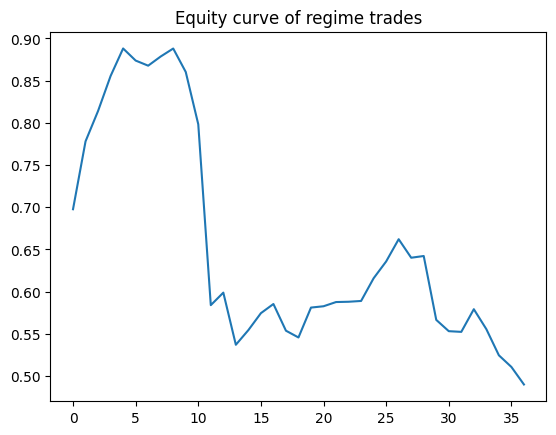

In [45]:
equity = np.cumprod(1 + trades)

import matplotlib.pyplot as plt

plt.plot(equity)
plt.title("Equity curve of regime trades")
plt.show()

In [46]:
import numpy as np

sorted_trades = np.sort(trades)

print("Worst 5:", sorted_trades[:5])
print("Best 5:", sorted_trades[-5:])
print("Median trade:", np.median(trades))

Worst 5: [-0.30233354 -0.26835953 -0.11778743 -0.10314538 -0.07207108]
Best 5: [0.04624601 0.0486223  0.05088341 0.06490559 0.11528634]
Median trade: 0.001584584099747377


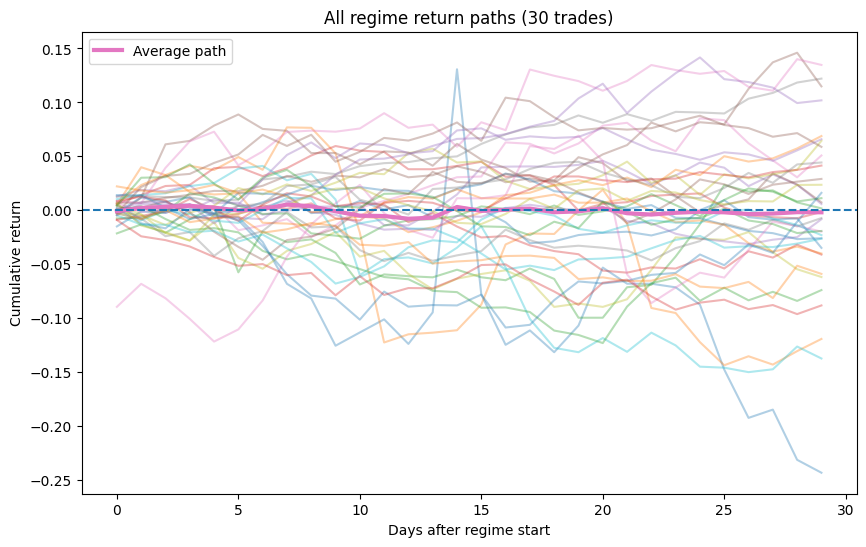

In [47]:
import numpy as np
import matplotlib.pyplot as plt

d = merged['corn'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)
d['ret'] = d[close_col].pct_change()

# regime start
d['signal_cross'] = (d['cot_idx'] > 0.9) & (d['cot_idx'].shift(1) <= 0.9)

horizon = 30
paths = []

for i in range(len(d)-horizon):

    if d['signal_cross'].iloc[i]:
        future = d['ret'].iloc[i+1:i+1+horizon].values
        paths.append(np.cumsum(future))

paths = np.array(paths)

plt.figure(figsize=(10,6))

# plot each trade
for p in paths:
    plt.plot(p, alpha=0.35)

# average path
avg_path = paths.mean(axis=0)
plt.plot(avg_path, linewidth=3, label="Average path")

plt.axhline(0, linestyle='--')
plt.title("All regime return paths (30 trades)")
plt.xlabel("Days after regime start")
plt.ylabel("Cumulative return")
plt.legend()
plt.show()

In [48]:
horizon = 30
check_day = 20

trades_rule = []

for i in range(len(d)-horizon):

    if d['signal_cross'].iloc[i]:

        path = d['ret'].iloc[i+1:i+1+horizon].cumsum()

        # early exit rule
        if path.iloc[check_day] <= 0:
            trades_rule.append(path.iloc[check_day])
        else:
            trades_rule.append(path.iloc[-1])

import numpy as np
trades_rule = np.array(trades_rule)

print("Trades:", len(trades_rule))
print("Mean:", trades_rule.mean())
print("Median:", np.median(trades_rule))
print("Win rate:", (trades_rule>0).mean())

Trades: 36
Mean: -0.00437070583028394
Median: -0.01369186941624162
Win rate: 0.4166666666666667


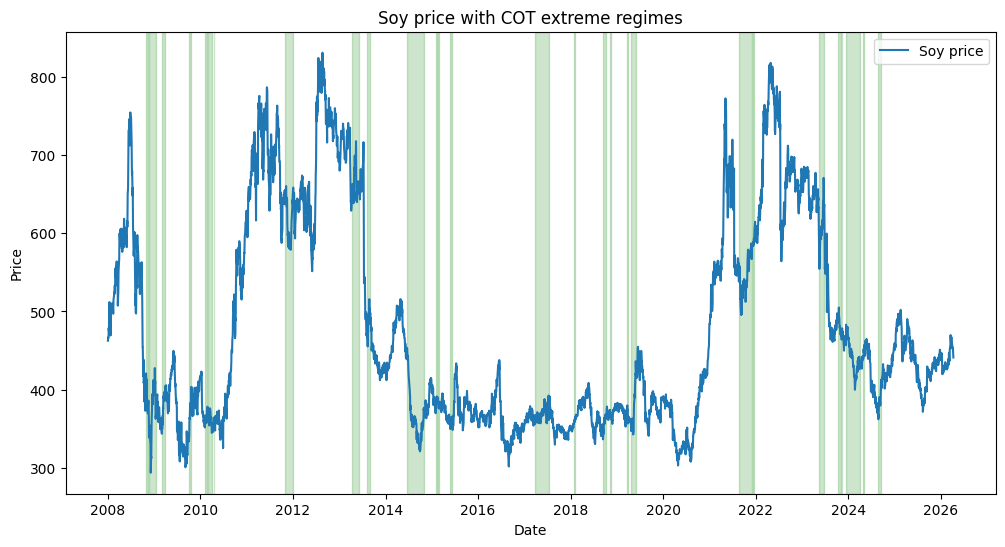

In [49]:
import matplotlib.pyplot as plt

d = merged['soy'].loc['2008':].copy()

close_col = next(c for c in d.columns if "Close" in c)

# regime condition
d['extreme'] = d['cot_idx'] > 0.9

regimes = []
in_regime = False
start = None

for i in range(len(d)):

    if d['extreme'].iloc[i] and not in_regime:
        start = d.index[i]
        in_regime = True

    elif not d['extreme'].iloc[i] and in_regime:
        end = d.index[i]
        regimes.append((start, end))
        in_regime = False

# handle regime lasting to end of dataset
if in_regime:
    regimes.append((start, d.index[-1]))

plt.figure(figsize=(12,6))
plt.plot(d.index, d[close_col], label="Soy price")

for s, e in regimes:
    plt.axvspan(s, e, color='green', alpha=0.2)

plt.title("Soy price with COT extreme regimes")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

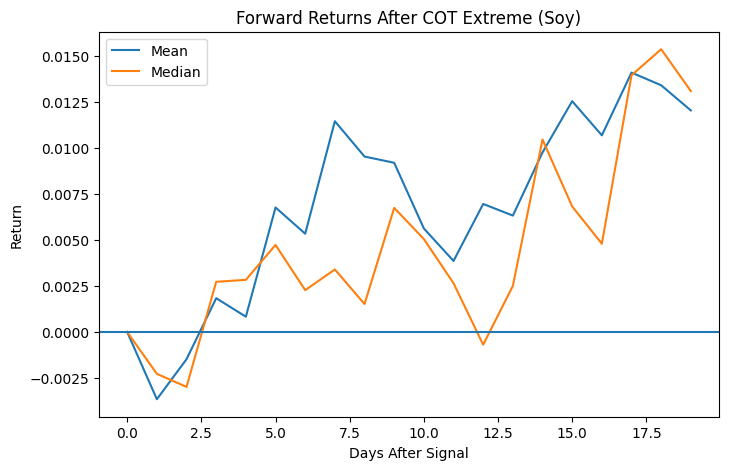

Independent signals: 38


In [50]:
import numpy as np
import matplotlib.pyplot as plt

d = merged['soy'].copy()

# find correct close column
close_col = [c for c in d.columns if "Close" in c][0]

# signal definition
d['signal'] = (d['cot_idx'] > 0.9).astype(int)

# regime start
d['start'] = (d['signal'] == 1) & (d['signal'].shift(1) == 0)

starts = d.index[d['start']]

horizon = 20
paths = []

for t in starts:
    
    loc = d.index.get_loc(t)

    if loc + horizon >= len(d):
        continue

    window = d[close_col].iloc[loc:loc+horizon]
    ret = window / window.iloc[0] - 1
    paths.append(ret.values)

paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)

plt.figure(figsize=(8,5))
plt.plot(mean_path, label="Mean")
plt.plot(median_path, label="Median")
plt.axhline(0)
plt.title("Forward Returns After COT Extreme (Soy)")
plt.xlabel("Days After Signal")
plt.ylabel("Return")
plt.legend()
plt.show()

print("Independent signals:", len(paths))

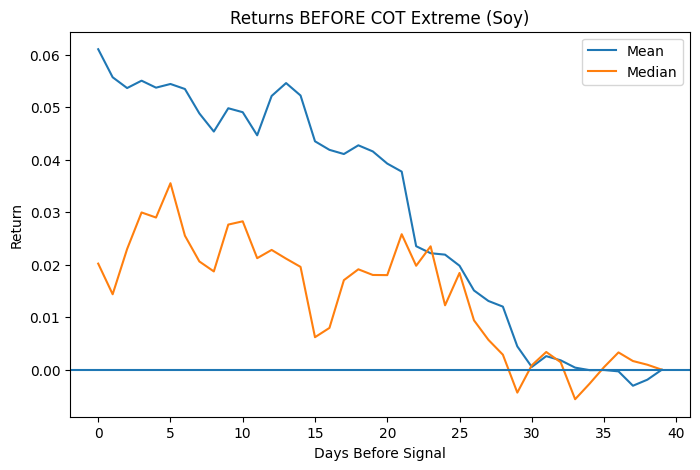

Signals used: 38


In [51]:
import numpy as np
import matplotlib.pyplot as plt

d = merged['soy'].copy()

close_col = [c for c in d.columns if "Close" in c][0]

d['signal'] = (d['cot_idx'] > 0.9).astype(int)
d['start'] = (d['signal'] == 1) & (d['signal'].shift(1) == 0)

starts = d.index[d['start']]

horizon = 40
paths_before = []

for t in starts:

    loc = d.index.get_loc(t)

    if loc - horizon < 0:
        continue

    window = d[close_col].iloc[loc-horizon:loc]
    ret = window / window.iloc[-1] - 1
    paths_before.append(ret.values)

paths_before = np.array(paths_before)

mean_before = paths_before.mean(axis=0)
median_before = np.median(paths_before, axis=0)

plt.figure(figsize=(8,5))
plt.plot(mean_before, label="Mean")
plt.plot(median_before, label="Median")
plt.axhline(0)

plt.title("Returns BEFORE COT Extreme (Soy)")
plt.xlabel("Days Before Signal")
plt.ylabel("Return")
plt.legend()

plt.show()

print("Signals used:", len(paths_before))

In [52]:
d = merged['soy'].copy()

close_col = [c for c in d.columns if "Close" in c][0]

# daily return
d['ret'] = d[close_col].pct_change()

# 20-day return BEFORE signal
d['ret20'] = d[close_col].pct_change(20)

# COT signal
d['signal'] = (d['cot_idx'] > 0.9)

# ensure boolean
prev_signal = d['signal'].shift(1).fillna(False)

d['start'] = d['signal'] & (~prev_signal)

horizon = 20

def forward_return(df, horizon):
    return df[close_col].shift(-horizon) / df[close_col] - 1

d['fwd20'] = forward_return(d, horizon)

signals = d[d['start']].copy()

print("All signals:", signals['fwd20'].mean())

for dd in [-0.05, -0.10, -0.15]:
    subset = signals[signals['ret20'] < dd]
    print(f"\nPrior 20d return < {dd}")
    print("signals:", len(subset))
    print("mean forward:", subset['fwd20'].mean())

All signals: 0.0064755123408025235

Prior 20d return < -0.05
signals: 260
mean forward: 0.021261891466306682

Prior 20d return < -0.1
signals: 82
mean forward: 0.05446481005087288

Prior 20d return < -0.15
signals: 28
mean forward: 0.09875129606798778


In [53]:
d = merged['soy'].copy()

close_col = [c for c in d.columns if "Close" in c][0]

# 20-day return BEFORE today
d['ret20'] = d[close_col].pct_change(20)

# 20-day return AFTER today
d['fwd20'] = d[close_col].shift(-20) / d[close_col] - 1

print("All days:", d['fwd20'].mean())

for dd in [-0.05, -0.10, -0.15]:
    
    subset = d[d['ret20'] < dd]
    
    print(f"\nPrior 20d return < {dd}")
    print("days:", len(subset))
    print("mean forward:", subset['fwd20'].mean())

All days: 0.006159031878777066

Prior 20d return < -0.05
days: 1275
mean forward: 0.008588794345606731

Prior 20d return < -0.1
days: 490
mean forward: 0.005777590903677652

Prior 20d return < -0.15
days: 213
mean forward: 0.00493076562253133


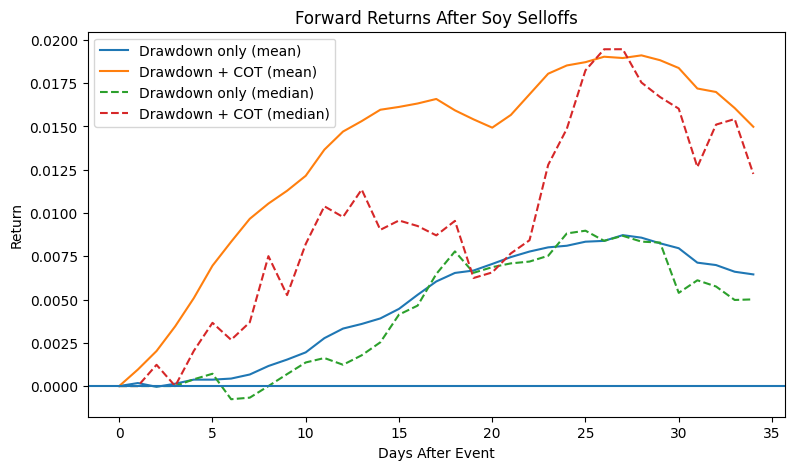

Drawdown events: 1855
Drawdown + COT events: 362


In [54]:
import numpy as np
import matplotlib.pyplot as plt

d = merged['soy'].copy()

close_col = [c for c in d.columns if "Close" in c][0]

# prior 20-day drawdown
d['ret20'] = d[close_col].pct_change(20)

# COT signal
d['cot_sig'] = d['cot_idx'] > 0.9

drawdown = d['ret20'] < -0.03
cot_drawdown = drawdown & d['cot_sig']

horizon = 35

def forward_paths(df, mask, horizon):
    paths = []

    idx = df.index[mask]

    for t in idx:
        loc = df.index.get_loc(t)

        if loc + horizon >= len(df):
            continue

        window = df[close_col].iloc[loc:loc+horizon]
        ret = window / window.iloc[0] - 1
        paths.append(ret.values)

    return np.array(paths)

paths_dd = forward_paths(d, drawdown, horizon)
paths_cot = forward_paths(d, cot_drawdown, horizon)

mean_dd = paths_dd.mean(axis=0)
mean_cot = paths_cot.mean(axis=0)

median_dd = np.median(paths_dd, axis=0)
median_cot = np.median(paths_cot, axis=0)

plt.figure(figsize=(9,5))

plt.plot(mean_dd, label="Drawdown only (mean)")
plt.plot(mean_cot, label="Drawdown + COT (mean)")

plt.plot(median_dd, "--", label="Drawdown only (median)")
plt.plot(median_cot, "--", label="Drawdown + COT (median)")

plt.axhline(0)

plt.title("Forward Returns After Soy Selloffs")
plt.xlabel("Days After Event")
plt.ylabel("Return")

plt.legend()
plt.show()

print("Drawdown events:", len(paths_dd))
print("Drawdown + COT events:", len(paths_cot))

In [55]:
trade_returns = []
trade_dates = []

entry_delay = 0
hold = 15

i = 0

d['ret20'] = d[close_col].pct_change(20)

d['signal'] = (d['cot_idx'] > 0.9)

while i < len(d):

    # check signal + drawdown condition
    if d['signal'].iloc[i] and d['ret20'].iloc[i] < -0.04:

        signal_loc = i
        entry_loc = signal_loc + entry_delay
        exit_loc  = entry_loc + hold

        if exit_loc >= len(d):
            break

        entry_price = d[close_col].iloc[entry_loc]
        exit_price  = d[close_col].iloc[exit_loc]

        trade_returns.append(exit_price / entry_price - 1)
        trade_dates.append(d.index[entry_loc])

        # skip forward to exit so trades can't overlap
        i = exit_loc
        continue

    i += 1

In [56]:
import numpy as np

trades = np.array(trade_returns)

mean = trades.mean()
std = trades.std()

# scale to annual assuming 20-day holding
sharpe = (mean / std) * np.sqrt(252 / hold)

print("Trades:", len(trades))
print("Mean:", mean)
print("Median:", np.median(trades))
print("Win rate:", (trades > 0).mean())
print("Sharpe:", sharpe)

Trades: 41
Mean: 0.01915796116308828
Median: 0.025352112676056304
Win rate: 0.6097560975609756
Sharpe: 1.183356300191216


In [57]:
import pandas as pd

trade_df = pd.DataFrame({
    "date": trade_dates,
    "ret": trade_returns
})

trade_df["year"] = trade_df["date"].dt.year

print(trade_df["year"].value_counts().sort_index())

year
2001    2
2003    3
2004    4
2005    1
2006    1
2008    3
2009    1
2010    3
2011    2
2013    3
2014    5
2017    2
2018    1
2019    1
2021    2
2023    3
2024    4
Name: count, dtype: int64


<Axes: title={'center': 'Hog COT Reversal Strategy'}>

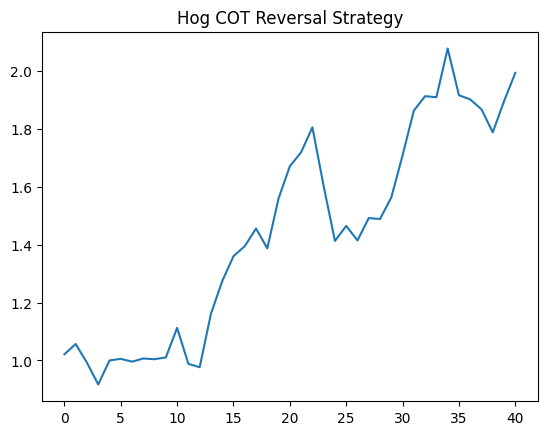

In [58]:
equity = (1 + pd.Series(trades)).cumprod()
equity.plot(title="Hog COT Reversal Strategy")

In [59]:
dd_windows = [5, 10, 15, 20, 25, 30, 40, 60, 90, 120]
dd_thresholds = [-0.01, -0.02, -0.03, -0.05, -0.08, -0.10]

In [60]:
import numpy as np
import pandas as pd

results = []

for w in dd_windows:

    d[f"ret{w}"] = d[close_col].pct_change(w)

    for dd in dd_thresholds:

        trade_returns = []
        i = 0

        while i < len(d):

            if d['signal'].iloc[i] and d[f"ret{w}"].iloc[i] < dd:

                entry_loc = i + entry_delay
                exit_loc  = entry_loc + hold

                if exit_loc >= len(d):
                    break

                entry_price = d[close_col].iloc[entry_loc]
                exit_price  = d[close_col].iloc[exit_loc]

                trade_returns.append(exit_price / entry_price - 1)

                i = exit_loc
                continue

            i += 1

        if len(trade_returns) > 5:

            r = np.array(trade_returns)

            sharpe = (r.mean() / r.std()) * np.sqrt(252 / hold)

        else:
            sharpe = np.nan

        results.append({
            "window": w,
            "drawdown": dd,
            "sharpe": sharpe,
            "trades": len(trade_returns)
        })

In [61]:
df = pd.DataFrame(results)

heat = df.pivot(index="drawdown", columns="window", values="sharpe")

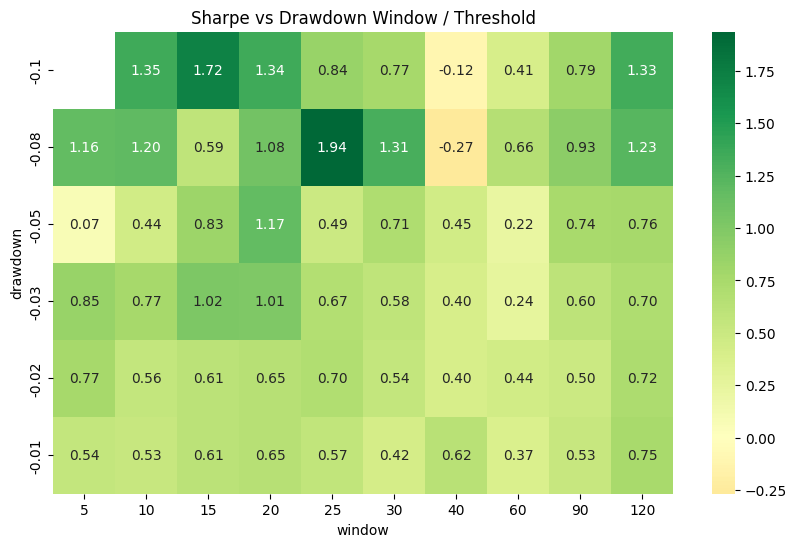

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Sharpe vs Drawdown Window / Threshold")
plt.show()

In [63]:
soy = merged['soy'].copy()

s_close_col = [c for c in soy.columns if "Close" in c][0]

s_trade_returns = []
s_trade_dates = []

entry_delay = 0
hold = 15

i = 0

soy['ret20'] = soy[s_close_col].pct_change(20)

soy['signal'] = (soy['cot_idx'] > 0.9)

soy['strat_ret'] = soy['signal'] * soy['ret']

while i < len(soy):

    # check signal + drawdown condition
    if soy['signal'].iloc[i] and soy['ret20'].iloc[i] < -0.04:

        signal_loc = i
        entry_loc = signal_loc + entry_delay
        exit_loc  = entry_loc + hold

        if exit_loc >= len(soy):
            break

        entry_price = soy[s_close_col].iloc[entry_loc]
        exit_price  = soy[s_close_col].iloc[exit_loc]

        s_trade_returns.append(exit_price / entry_price - 1)
        s_trade_dates.append(soy.index[entry_loc])

        # skip forward to exit so trades can't overlap
        i = exit_loc
        continue

    i += 1

In [64]:
d = merged['hogs'].copy()

close_col = [c for c in d.columns if "Close" in c][0]

trade_returns = []
trade_dates = []

entry_delay = 5
hold = 20

i = 0

d['ret20'] = d[close_col].pct_change(60)

d['signal'] = d['cot_idx'] > 0.8

d['strat_ret'] = d['signal'] * d['ret']

while i < len(d):

    # check signal + drawdown condition
    if d['signal'].iloc[i] and d['ret20'].iloc[i] < -0.08:

        signal_loc = i
        entry_loc = signal_loc + entry_delay
        exit_loc  = entry_loc + hold

        if exit_loc >= len(d):
            break

        entry_price = d[close_col].iloc[entry_loc]
        exit_price  = d[close_col].iloc[exit_loc]

        trade_returns.append(exit_price / entry_price - 1)
        trade_dates.append(d.index[entry_loc])

        # skip forward to exit so trades can't overlap
        i = exit_loc
        continue

    i += 1

In [65]:
hogs_df = pd.DataFrame({
    "date": trade_dates,
    "ret": trade_returns
}).sort_values("date")

soy_df = pd.DataFrame({
    "date": s_trade_dates,
    "ret": s_trade_returns
}).sort_values("date")

In [67]:
hog_hold = 20
soy_hold = 15

hogs_df["daily_ret"] = (1 + hogs_df["ret"])**(1/hog_hold) - 1
soy_df["daily_ret"]  = (1 + soy_df["ret"])**(1/soy_hold) - 1

hogs_df["exit"] = hogs_df["date"] + pd.Timedelta(days=hog_hold)
soy_df["exit"]  = soy_df["date"] + pd.Timedelta(days=soy_hold)

In [73]:
start_equity = 100000000
position_fraction = 0.05

dates = pd.date_range(
    min(hogs_df["date"].min(), soy_df["date"].min()),
    max(hogs_df["exit"].max(), soy_df["exit"].max()),
    freq="D"
)

equity = start_equity

portfolio_curve = []
hogs_pnl = []
soy_pnl = []

for d in dates:

    hog_ret = 0
    soy_ret = 0

    active_hogs = hogs_df[
        (hogs_df["date"] <= d) & (hogs_df["exit"] > d)
    ]

    active_soy = soy_df[
        (soy_df["date"] <= d) & (soy_df["exit"] > d)
    ]

    if len(active_hogs) > 0:
        hog_ret = active_hogs["daily_ret"].sum()

    if len(active_soy) > 0:
        soy_ret = active_soy["daily_ret"].sum()

    equity *= (1 + hog_ret * position_fraction)
    equity *= (1 + soy_ret * position_fraction)

    portfolio_curve.append(equity)
    hogs_pnl.append(position_fraction * hog_ret)
    soy_pnl.append(position_fraction * soy_ret)

In [74]:
equity_df = pd.DataFrame({
    "date": dates,
    "portfolio": portfolio_curve,
    "hogs_ret": hogs_pnl,
    "soy_ret": soy_pnl
}).set_index("date")

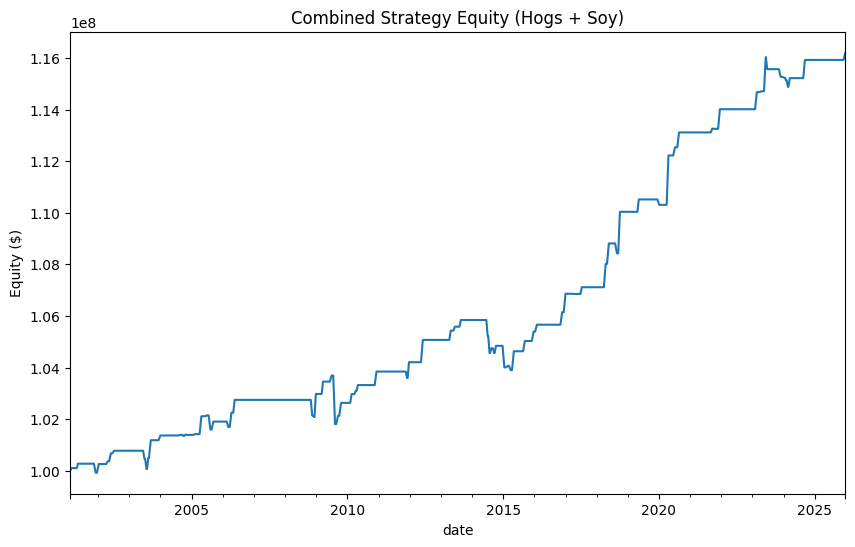

In [75]:
import matplotlib.pyplot as plt

equity_df["portfolio"].plot(figsize=(10,6))
plt.title("Combined Strategy Equity (Hogs + Soy)")
plt.ylabel("Equity ($)")
plt.show()

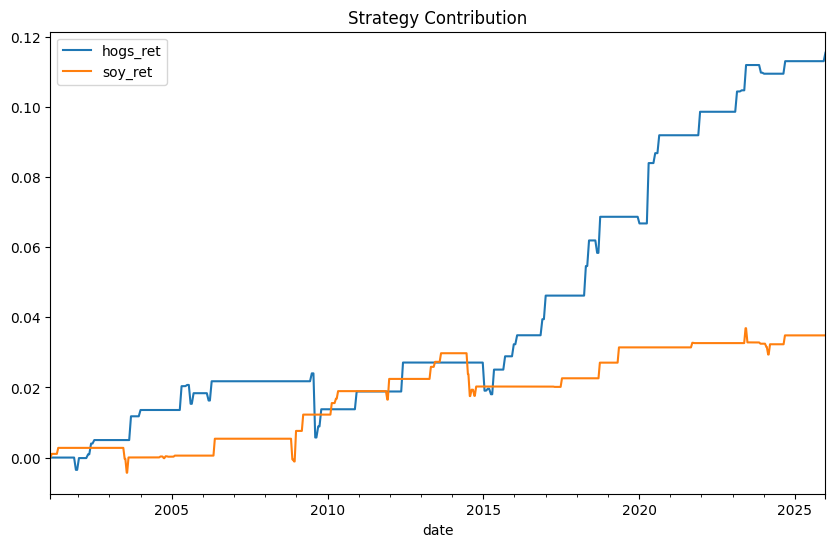

In [76]:
(equity_df[["hogs_ret","soy_ret"]].cumsum()).plot(figsize=(10,6))
plt.title("Strategy Contribution")
plt.show()

In [77]:
equity_df["daily_ret"] = equity_df["portfolio"].pct_change()

In [78]:
annual_returns = equity_df["daily_ret"].groupby(equity_df.index.year).apply(
    lambda x: (1 + x).prod() - 1
)

print((annual_returns * 100).round(2))

date
2001    0.14
2002    0.63
2003    0.58
2004    0.02
2005    0.51
2006    0.83
2007    0.00
2008    0.22
2009   -0.33
2010    1.18
2011    0.35
2012    0.83
2013    0.73
2014   -1.18
2015    0.77
2016    1.40
2017    0.23
2018    2.73
2019    0.28
2020    2.51
2021    0.79
2022    0.00
2023    1.08
2024    0.59
2025    0.24
Name: daily_ret, dtype: float64


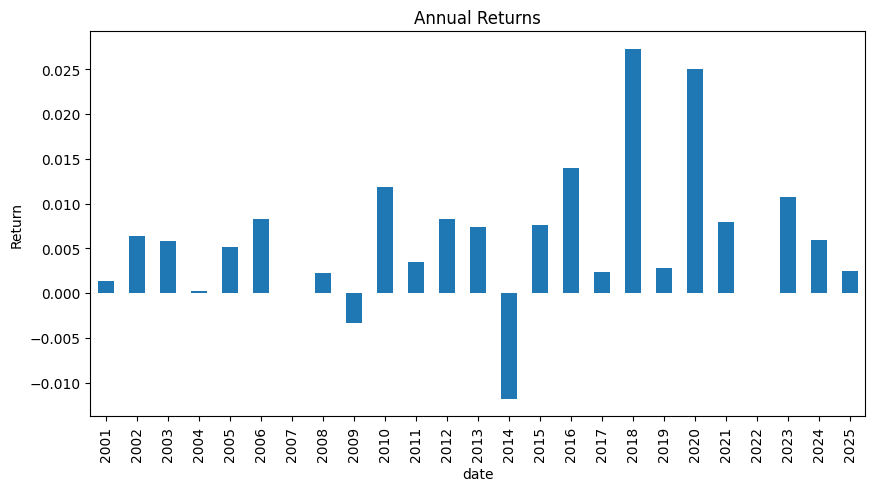

In [79]:
annual_returns.plot(kind="bar", figsize=(10,5))
plt.title("Annual Returns")
plt.ylabel("Return")
plt.show()

In [80]:
years = len(equity_df) / 252
cagr = (equity_df["portfolio"].iloc[-1] / equity_df["portfolio"].iloc[0])**(1/years) - 1
print("CAGR:", cagr)

CAGR: 0.004171002259163892


In [81]:
sharpe = equity_df["daily_ret"].mean() / equity_df["daily_ret"].std() * np.sqrt(252)
print("Sharpe:", sharpe)

Sharpe: 2.3001894745964826


In [82]:
rolling_max = equity_df["portfolio"].cummax()
drawdown = equity_df["portfolio"] / rolling_max - 1
drawdown.min()

np.float64(-0.018361313597636486)

In [83]:
min(trade_returns)

np.float64(-0.30858469129275456)